# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import joblib
import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


# Load Dataset

In [4]:
df = pd.read_csv("../data/emi_prediction_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (404800, 27)


In [5]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,...,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,...,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,...,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,...,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,...,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [6]:
df.tail()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
404795,27.0,Male,Married,Graduate,32400.0,Private,5.0,Large Indian,Rented,10400.0,...,No,0.0,649.0,62000.0,32600.0,Personal Loan EMI,506000.0,47,Not_Eligible,500.0
404796,38.0,Male,Married,Post Graduate,49200.0,Private,1.9,MNC,Own,0.0,...,No,0.0,712.0,142200.0,38100.0,Personal Loan EMI,708000.0,33,Not_Eligible,5200.0
404797,32.0,Male,Single,Graduate,25700.0,Private,3.2,MNC,Rented,6300.0,...,No,0.0,676.0,191600.0,39700.0,Home Appliances EMI,93000.0,21,High_Risk,5665.0
404798,48.0,Male,Married,Graduate,47200.0,Private,3.0,MNC,Own,0.0,...,No,0.0,784.0,170400.0,45600.0,Home Appliances EMI,144000.0,36,Eligible,14460.0
404799,38.0,FEMALE,Married,Graduate,34900.0,Private,1.2,MNC,Family,0.0,...,No,0.0,641.0,214400.0,99400.0,Home Appliances EMI,77000.0,35,Eligible,8756.0


In [7]:
df.columns.tolist()

['age',
 'gender',
 'marital_status',
 'education',
 'monthly_salary',
 'employment_type',
 'years_of_employment',
 'company_type',
 'house_type',
 'monthly_rent',
 'family_size',
 'dependents',
 'school_fees',
 'college_fees',
 'travel_expenses',
 'groceries_utilities',
 'other_monthly_expenses',
 'existing_loans',
 'current_emi_amount',
 'credit_score',
 'bank_balance',
 'emergency_fund',
 'emi_scenario',
 'requested_amount',
 'requested_tenure',
 'emi_eligibility',
 'max_monthly_emi']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 404800
Number of columns: 27


In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,404800.0,41.0,38.0,91577.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,404800,8,Male,237427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,404800,2,Married,307837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,402396,4,Graduate,181015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_salary,404800,13662,18000.0,4159,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_type,404800,3,Private,283099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_of_employment,404800.0,NaN,NaN,NaN,5.364079,6.079135,0.5,1.2,3.2,7.2,36.0
company_type,404800,5,Large Indian,121139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
house_type,404800,3,Rented,161601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_rent,402374.0,NaN,NaN,NaN,5828.44649,8648.604639,0.0,0.0,0.0,10600.0,80000.0


# Missing Values

In [11]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing_Count": missing_values.values,
    "Missing_Percentage": (missing_values.values / len(df)) * 100
})

missing_table = missing_table.sort_values(
    by="Missing_Count",
    ascending=False
)

missing_table

,Column,Missing_Count,Missing_Percentage
20,bank_balance,2426,0.599308
9,monthly_rent,2426,0.599308
19,credit_score,2420,0.597826
3,education,2404,0.593874
21,emergency_fund,2351,0.580781
0,age,0,0.000000
15,groceries_utilities,0,0.000000
25,emi_eligibility,0,0.000000
24,requested_tenure,0,0.000000
23,requested_amount,0,0.000000


# Duplicate Check

In [12]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


# Target Column Check

In [13]:
print("Classification target:")
print(df["emi_eligibility"].value_counts(dropna=False))

Classification target:
emi_eligibility
Not_Eligible    312868
Eligible         74444
High_Risk        17488
Name: count, dtype: int64


In [14]:
print("\nRegression target:")
print(df["max_monthly_emi"].describe())


Regression target:
count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64


# Check Categorical Columns

In [15]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['age', 'gender', 'marital_status', 'education', 'monthly_salary', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'bank_balance', 'emi_scenario', 'emi_eligibility']


# Check Numerical Columns

In [16]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'emergency_fund', 'requested_amount', 'requested_tenure', 'max_monthly_emi']


# Data Cleaning

In [17]:
df_clean = df.copy()

print("Working copy created.")
print("Shape:", df_clean.shape)

Working copy created.
Shape: (404800, 27)


# Remove Duplicates

In [18]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates()

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 404800
Rows after: 404800
Duplicates removed: 0


# Handle Missing Values

In [22]:
numerical_columns = df_clean.select_dtypes(
    include=np.number
).columns.tolist()

for col in numerical_columns:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].median()
    )

In [23]:
categorical_columns = df_clean.select_dtypes(
    include=["object", "category"]
).columns.tolist()

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].mode()[0]
    )

In [24]:
print("Total missing values:", df_clean.isnull().sum().sum())

Total missing values: 0


In [25]:
# Financial columns that should contain numeric values

financial_columns = [
    "monthly_salary",
    "monthly_rent",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses",
    "current_emi_amount",
    "credit_score",
    "bank_balance",
    "emergency_fund",
    "requested_amount",
    "requested_tenure"
]

# Convert text values to numeric
# Invalid values will become NaN

for col in financial_columns:
    df_clean[col] = pd.to_numeric(
        df_clean[col],
        errors="coerce"
    )

print("Financial columns converted to numeric.")

Financial columns converted to numeric.


In [26]:
print("Missing values created:")
print(df_clean[financial_columns].isnull().sum())

Missing values created:
monthly_salary            0
monthly_rent              0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
requested_amount          0
requested_tenure          0
dtype: int64


In [27]:
for col in financial_columns:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].median()
    )

print("Missing financial values handled.")

Missing financial values handled.


In [28]:
print(
    "Total missing values in financial columns:",
    df_clean[financial_columns].isnull().sum().sum()
)

Total missing values in financial columns: 0


In [30]:
# Columns that should contain numeric values

numeric_expected = [
    "age",
    "monthly_salary",
    "years_of_employment",
    "monthly_rent",
    "family_size",
    "dependents",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses",
    "current_emi_amount",
    "credit_score",
    "bank_balance",
    "emergency_fund",
    "requested_amount",
    "requested_tenure",
    "max_monthly_emi"
]

# Convert these columns to numeric
# Invalid values such as "58.0.0" become NaN

for col in numeric_expected:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(
            df_clean[col],
            errors="coerce"
        )

print("Numeric conversion completed.")

Numeric conversion completed.


In [31]:
# Check how many missing values were created
# because of invalid numeric entries

numeric_check = df_clean[numeric_expected].isnull().sum()

print(numeric_check[numeric_check > 0])

age    3
dtype: int64


In [32]:
# Fill numeric missing values with median

for col in numeric_expected:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(
            df_clean[col].median()
        )

print(
    "Total missing numeric values:",
    df_clean[numeric_expected].isnull().sum().sum()
)

Total missing numeric values: 0


# EDA

## Eligibility Distribution

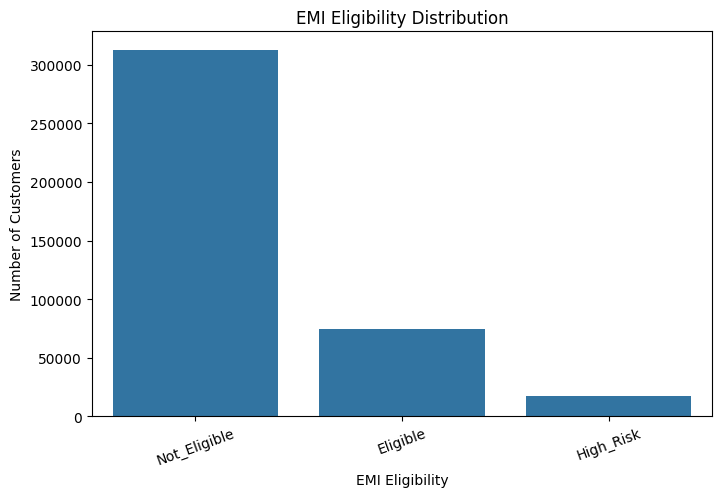

In [33]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="emi_eligibility"
)

plt.title("EMI Eligibility Distribution")
plt.xlabel("EMI Eligibility")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

# Age Distribution

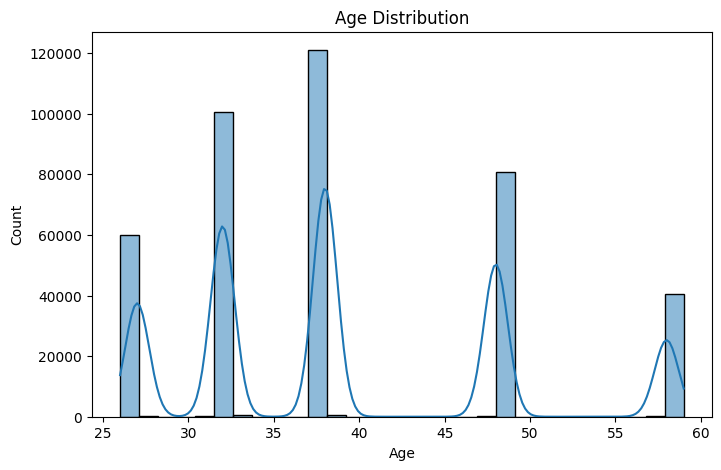

In [34]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Salary Distribution

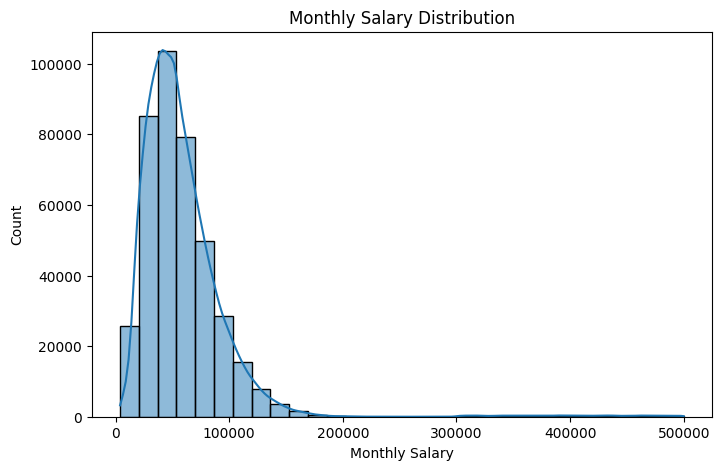

In [35]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="monthly_salary",
    bins=30,
    kde=True
)

plt.title("Monthly Salary Distribution")
plt.xlabel("Monthly Salary")
plt.ylabel("Count")
plt.show()

# Credit Score Distribution

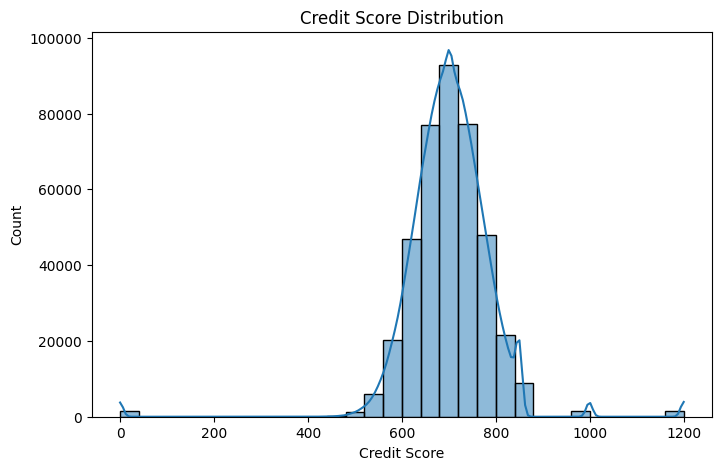

In [36]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="credit_score",
    bins=30,
    kde=True
)

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Count")
plt.show()

# Eligibility vs Credit Score

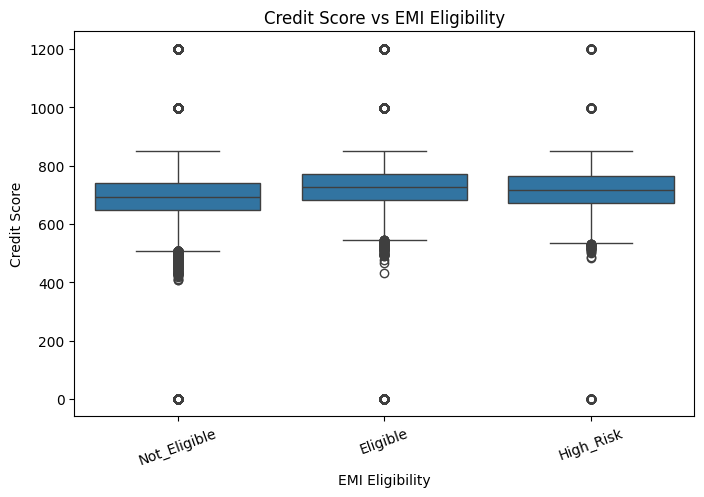

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="emi_eligibility",
    y="credit_score"
)

plt.title("Credit Score vs EMI Eligibility")
plt.xlabel("EMI Eligibility")
plt.ylabel("Credit Score")
plt.xticks(rotation=20)
plt.show()

# Correlation Heatmap

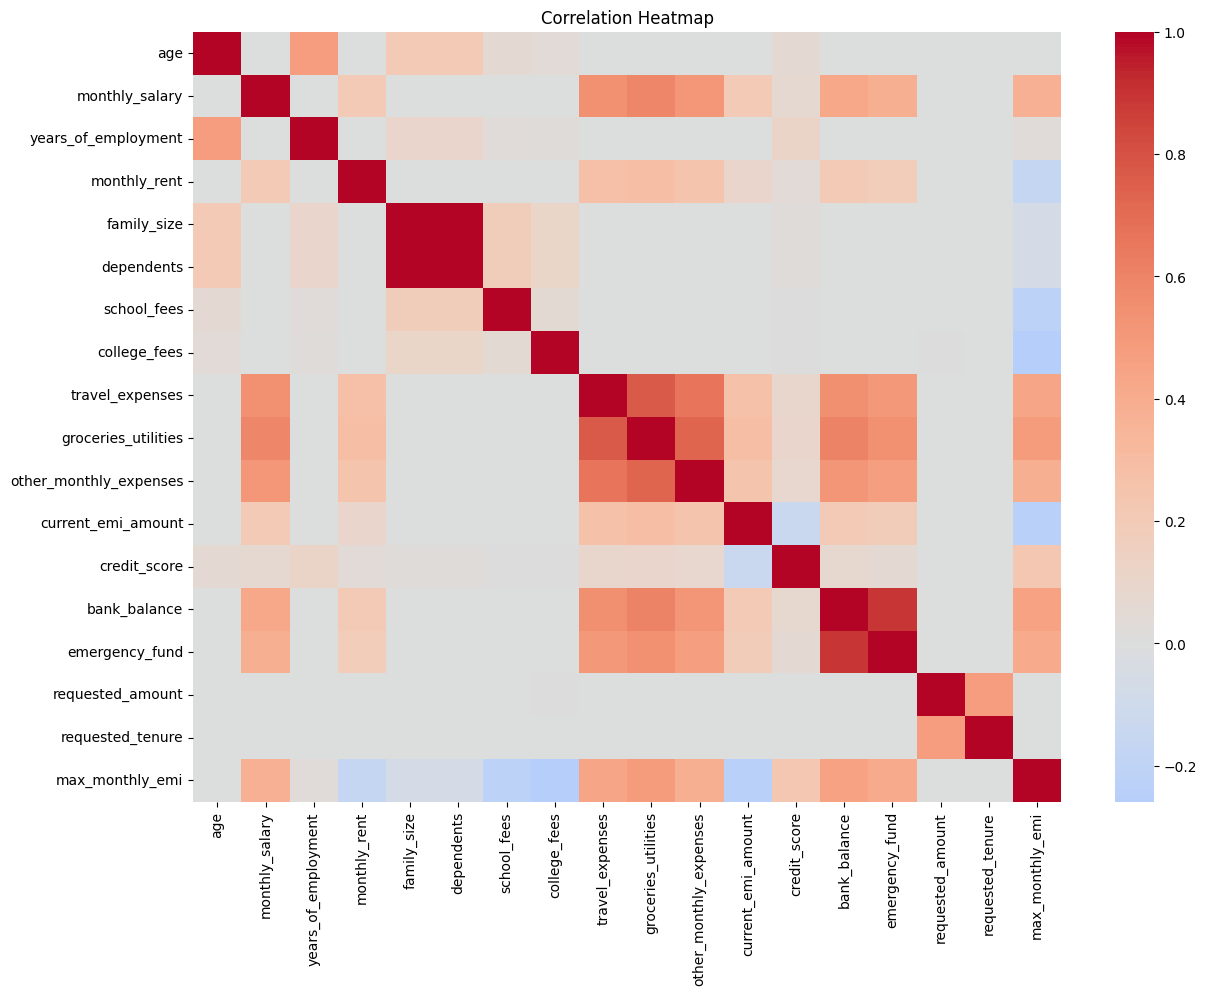

In [38]:
plt.figure(figsize=(14, 10))

correlation = df_clean.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

# Feature Engineering

In [39]:
df_clean["emi_to_income_ratio"] = (
    df_clean["current_emi_amount"] /
    df_clean["monthly_salary"].replace(0, np.nan)
)

df_clean["rent_to_income_ratio"] = (
    df_clean["monthly_rent"] /
    df_clean["monthly_salary"].replace(0, np.nan)
)

df_clean["expense_to_income_ratio"] = (
    (
        df_clean["school_fees"] +
        df_clean["college_fees"] +
        df_clean["travel_expenses"] +
        df_clean["groceries_utilities"] +
        df_clean["other_monthly_expenses"]
    ) /
    df_clean["monthly_salary"].replace(0, np.nan)
)

df_clean["debt_to_income_ratio"] = (
    df_clean["current_emi_amount"] /
    df_clean["monthly_salary"].replace(0, np.nan)
)


In [40]:
df_clean = df_clean.replace(
    [np.inf, -np.inf],
    np.nan
)

df_clean = df_clean.fillna(0)

In [41]:
df_clean[
    [
        "emi_to_income_ratio",
        "rent_to_income_ratio",
        "expense_to_income_ratio",
        "debt_to_income_ratio"
    ]
].head()

,emi_to_income_ratio,rent_to_income_ratio,expense_to_income_ratio,debt_to_income_ratio
0,0.286925,0.242131,0.483051,0.286925
1,0.190698,0.000000,0.716279,0.190698
2,0.000000,0.000000,0.413473,0.000000
3,0.000000,0.000000,0.559880,0.000000
4,0.000000,0.000000,1.022688,0.000000


# Prepare Classification Data

In [42]:
X_class = df_clean.drop(
    columns=["emi_eligibility", "max_monthly_emi"]
)

y_class = df_clean["emi_eligibility"]

print("X shape:", X_class.shape)
print("y shape:", y_class.shape)

X shape: (404800, 29)
y shape: (404800,)


# Encode Classification Target

In [43]:
label_encoder = LabelEncoder()

y_class_encoded = label_encoder.fit_transform(y_class)

print("Classes:")
print(label_encoder.classes_)


Classes:
['Eligible' 'High_Risk' 'Not_Eligible']


# Train/Test Split for Classification

In [44]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_class_encoded
)

print("Training data:", X_train_class.shape)
print("Testing data:", X_test_class.shape)

Training data: (323840, 29)
Testing data: (80960, 29)


# Prepare Categorical + Numerical Features

In [45]:
categorical_features = X_train_class.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train_class.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: ['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario']
Numerical: ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'emi_to_income_ratio', 'rent_to_income_ratio', 'expense_to_income_ratio', 'debt_to_income_ratio']


In [46]:
# Convert all categorical columns to string

for col in categorical_features:
    X_train_class[col] = X_train_class[col].astype(str)
    X_test_class[col] = X_test_class[col].astype(str)

print("Categorical columns converted to string.")

Categorical columns converted to string.


# Preprocessing Pipeline

In [47]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor updated successfully.")

Preprocessor updated successfully.


# Classification Model 1: Logistic Regression

In [48]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000
        ))
    ]
)

logistic_model.fit(
    X_train_class,
    y_train_class
)

logistic_pred = logistic_model.predict(
    X_test_class
)

print("Logistic Regression completed.")

Logistic Regression completed.


# Classification Model 2: Random Forest

In [49]:
rf_classifier = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_classifier.fit(
    X_train_class,
    y_train_class
)

rf_class_pred = rf_classifier.predict(X_test_class)

print("Random Forest Classifier completed.")


Random Forest Classifier completed.


# Classification Model 3: XGBoost

In [50]:
xgb_classifier = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            eval_metric="mlogloss"
        ))
    ]
)

xgb_classifier.fit(
    X_train_class,
    y_train_class
)

xgb_class_pred = xgb_classifier.predict(X_test_class)

print("XGBoost Classifier completed.")


XGBoost Classifier completed.


# Classification Comparison

In [51]:
classification_results = []

models_classification = {
    "Logistic Regression": (
        logistic_model,
        logistic_pred
    ),
    "Random Forest": (
        rf_classifier,
        rf_class_pred
    ),
    "XGBoost": (
        xgb_classifier,
        xgb_class_pred
    )
}

for name, (model, predictions) in models_classification.items():

    accuracy = accuracy_score(
        y_test_class,
        predictions
    )

    precision = precision_score(
        y_test_class,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_class,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_class,
        predictions,
        average="weighted",
        zero_division=0
    )

    classification_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

classification_results_df = pd.DataFrame(
    classification_results
)

classification_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,XGBoost,0.947579,0.922185,0.947579,0.926813
1,Random Forest,0.931546,0.931366,0.931546,0.911390
0,Logistic Regression,0.892527,0.860260,0.892527,0.872965


# Classification Report

In [52]:
print(
    classification_report(
        y_test_class,
        xgb_class_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

    Eligible       0.92      0.96      0.94     14889
   High_Risk       0.36      0.00      0.00      3497
Not_Eligible       0.95      1.00      0.98     62574

    accuracy                           0.95     80960
   macro avg       0.74      0.65      0.64     80960
weighted avg       0.92      0.95      0.93     80960



# Prepare Regression Data

In [53]:
X_reg = df_clean.drop(
    columns=["emi_eligibility", "max_monthly_emi"]
)

y_reg = df_clean["max_monthly_emi"]

print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

X shape: (404800, 29)
y shape: (404800,)


# Regression Train/Test Split

In [54]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train_reg.shape)
print("Testing data:", X_test_reg.shape)

Training data: (323840, 29)
Testing data: (80960, 29)


# Regression Preprocessor

In [57]:
# Convert categorical columns to strings

for col in categorical_features_reg:
    X_train_reg[col] = X_train_reg[col].astype(str)
    X_test_reg[col] = X_test_reg[col].astype(str)

print("Regression categorical columns converted to string.")

Regression categorical columns converted to string.


In [58]:
categorical_features_reg = X_train_reg.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features_reg = X_train_reg.select_dtypes(
    include=np.number
).columns.tolist()

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numerical_features_reg
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(
                    handle_unknown="ignore"
                ))
            ]),
            categorical_features_reg
        )
    ]
)

# Regression : LinearRegression

In [59]:
numeric_transformer_reg = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_reg = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

reg_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_reg,
            numerical_features_reg
        ),
        (
            "cat",
            categorical_transformer_reg,
            categorical_features_reg
        )
    ]
)

print("Regression preprocessor updated successfully.")

Regression preprocessor updated successfully.


In [60]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(
    X_train_reg,
    y_train_reg
)

linear_pred = linear_model.predict(
    X_test_reg
)

print("Linear Regression completed.")

Linear Regression completed.


# Randomforest Regressor

In [61]:
rf_regressor = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_regressor.fit(
    X_train_reg,
    y_train_reg
)

rf_reg_pred = rf_regressor.predict(
    X_test_reg
)

print("Random Forest Regressor completed.")

Random Forest Regressor completed.


# XGBoost Regressor

In [62]:
xgb_regressor = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("model", XGBRegressor(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            random_state=42,
            objective="reg:squarederror"
        ))
    ]
)

xgb_regressor.fit(
    X_train_reg,
    y_train_reg
)

xgb_reg_pred = xgb_regressor.predict(
    X_test_reg
)

print("XGBoost Regressor completed.")

XGBoost Regressor completed.


# Regression Comparison

In [63]:
regression_results = []

models_regression = {
    "Linear Regression": (
        linear_model,
        linear_pred
    ),
    "Random Forest": (
        rf_regressor,
        rf_reg_pred
    ),
    "XGBoost": (
        xgb_regressor,
        xgb_reg_pred
    )
}

for name, (model, predictions) in models_regression.items():

    rmse = np.sqrt(
        mean_squared_error(
            y_test_reg,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test_reg,
        predictions
    )

    r2 = r2_score(
        y_test_reg,
        predictions
    )

    mape = np.mean(
        np.abs(
            (y_test_reg - predictions) /
            np.where(y_test_reg == 0, 1, y_test_reg)
        )
    ) * 100

    regression_results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    })

regression_results_df = pd.DataFrame(
    regression_results
)

regression_results_df.sort_values(
    by="RMSE",
    ascending=True
)

,Model,RMSE,MAE,R2,MAPE
1,Random Forest,944.148880,395.730567,0.984901,8.283788
2,XGBoost,948.540837,535.955593,0.984760,25.360082
0,Linear Regression,4117.393412,2961.390339,0.712840,192.434218


# Select Best Models

In [64]:
best_classification_name = (
    classification_results_df
    .sort_values("F1 Score", ascending=False)
    .iloc[0]["Model"]
)

best_regression_name = (
    regression_results_df
    .sort_values("RMSE", ascending=True)
    .iloc[0]["Model"]
)

print("Best Classification Model:", best_classification_name)
print("Best Regression Model:", best_regression_name)

Best Classification Model: XGBoost
Best Regression Model: Random Forest


# Save Best Classification Model

In [65]:
classification_models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_classifier,
    "XGBoost": xgb_classifier
}

best_classification_model = classification_models[
    best_classification_name
]

joblib.dump(
    best_classification_model,
    "../models/classification_model.pkl"
)

joblib.dump(
    label_encoder,
    "../models/classification_label_encoder.pkl"
)

print("Best classification model saved!")

Best classification model saved!


# Save Best Regression Model

In [66]:
regression_models = {
    "Linear Regression": linear_model,
    "Random Forest": rf_regressor,
    "XGBoost": xgb_regressor
}

best_regression_model = regression_models[
    best_regression_name
]

joblib.dump(
    best_regression_model,
    "../models/regression_model.pkl"
)

print("Best regression model saved!")

Best regression model saved!


# Final Model Files Check

In [67]:
import os

print("Model files:")

for file in os.listdir("../models"):
    print(file)

Model files:
classification_label_encoder.pkl
classification_model.pkl
regression_model.pkl


In [69]:
import mlflow
import mlflow.sklearn
mlflow.set_experiment("EMIPredict_AI")

print("MLflow experiment is ready.")

2026/08/31 13:07:57 INFO mlflow.tracking.fluent: Experiment with name 'EMIPredict_AI' does not exist. Creating a new experiment.


MLflow experiment is ready.
